In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') 

In [52]:
df = pd.read_csv('/home/ali-mirza/AI-ML-DS-PROJECTS/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
df.shape

(7043, 21)

In [54]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [56]:
df = df.drop(['customerID'],axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


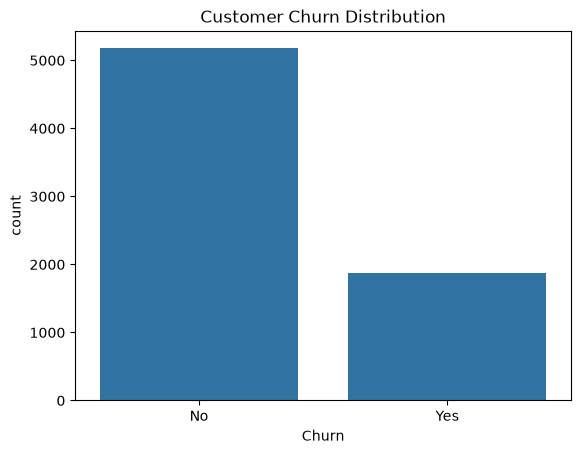

In [57]:
sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.show()

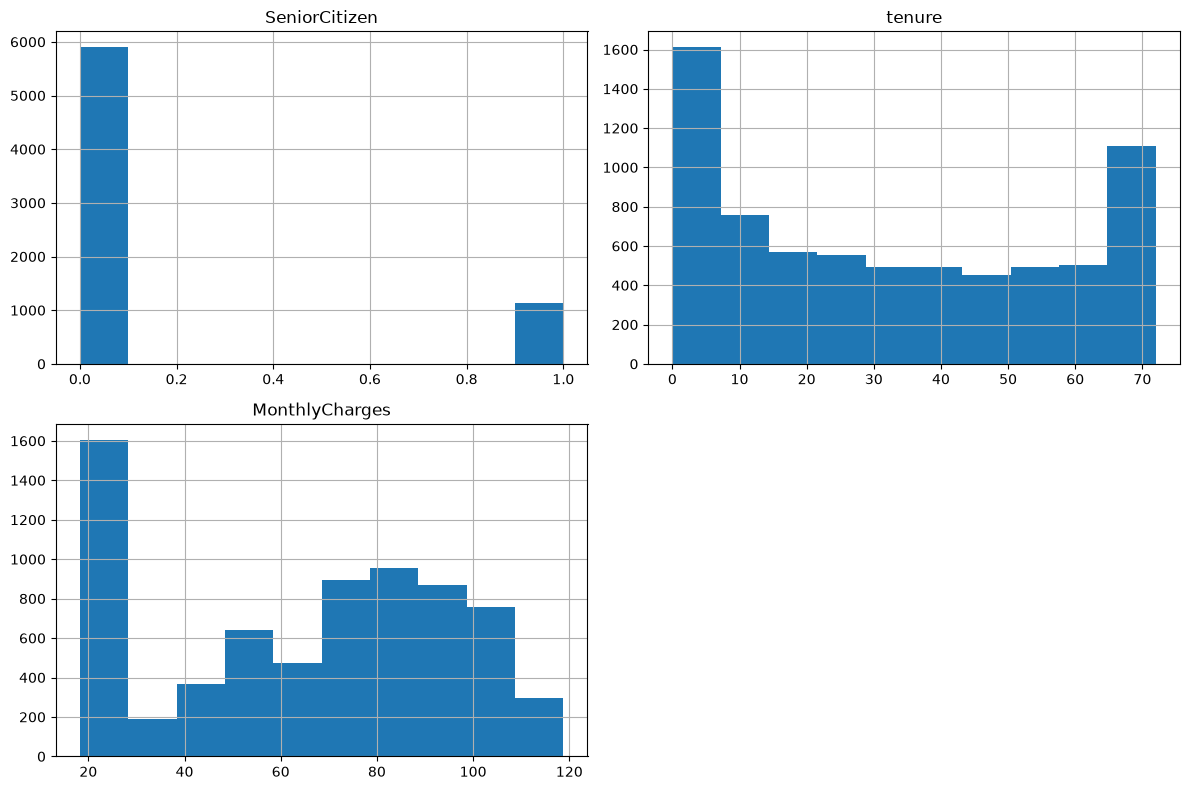

In [58]:
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols].hist(figsize=(12, 8))

plt.tight_layout()
plt.show()

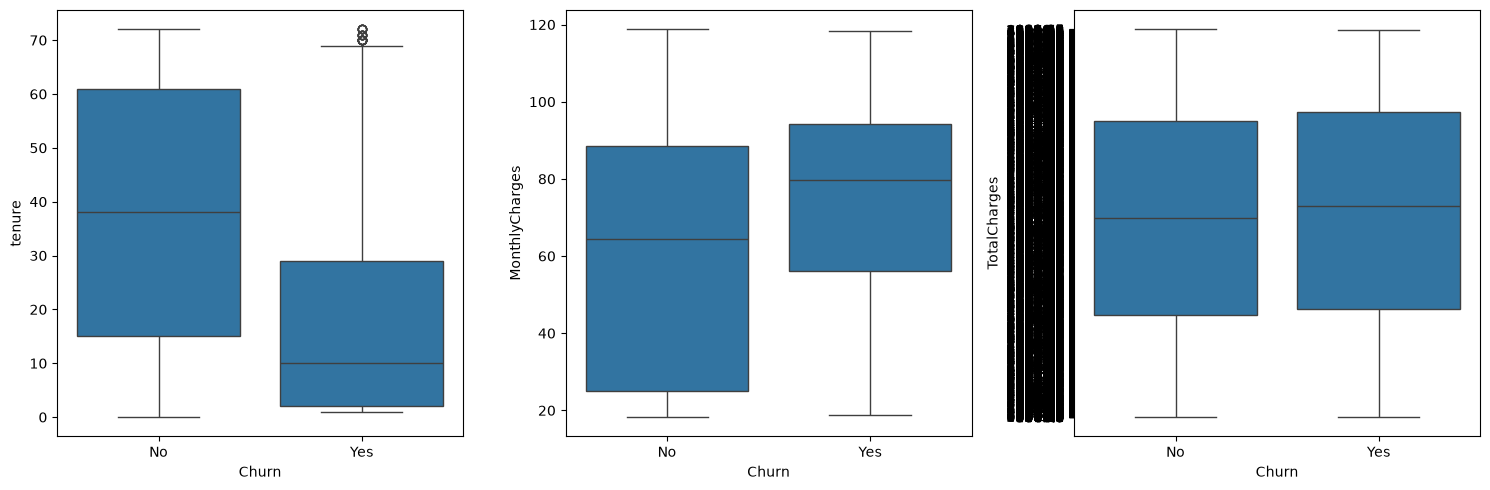

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[2])

plt.tight_layout()
plt.show()

In [60]:
cat_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

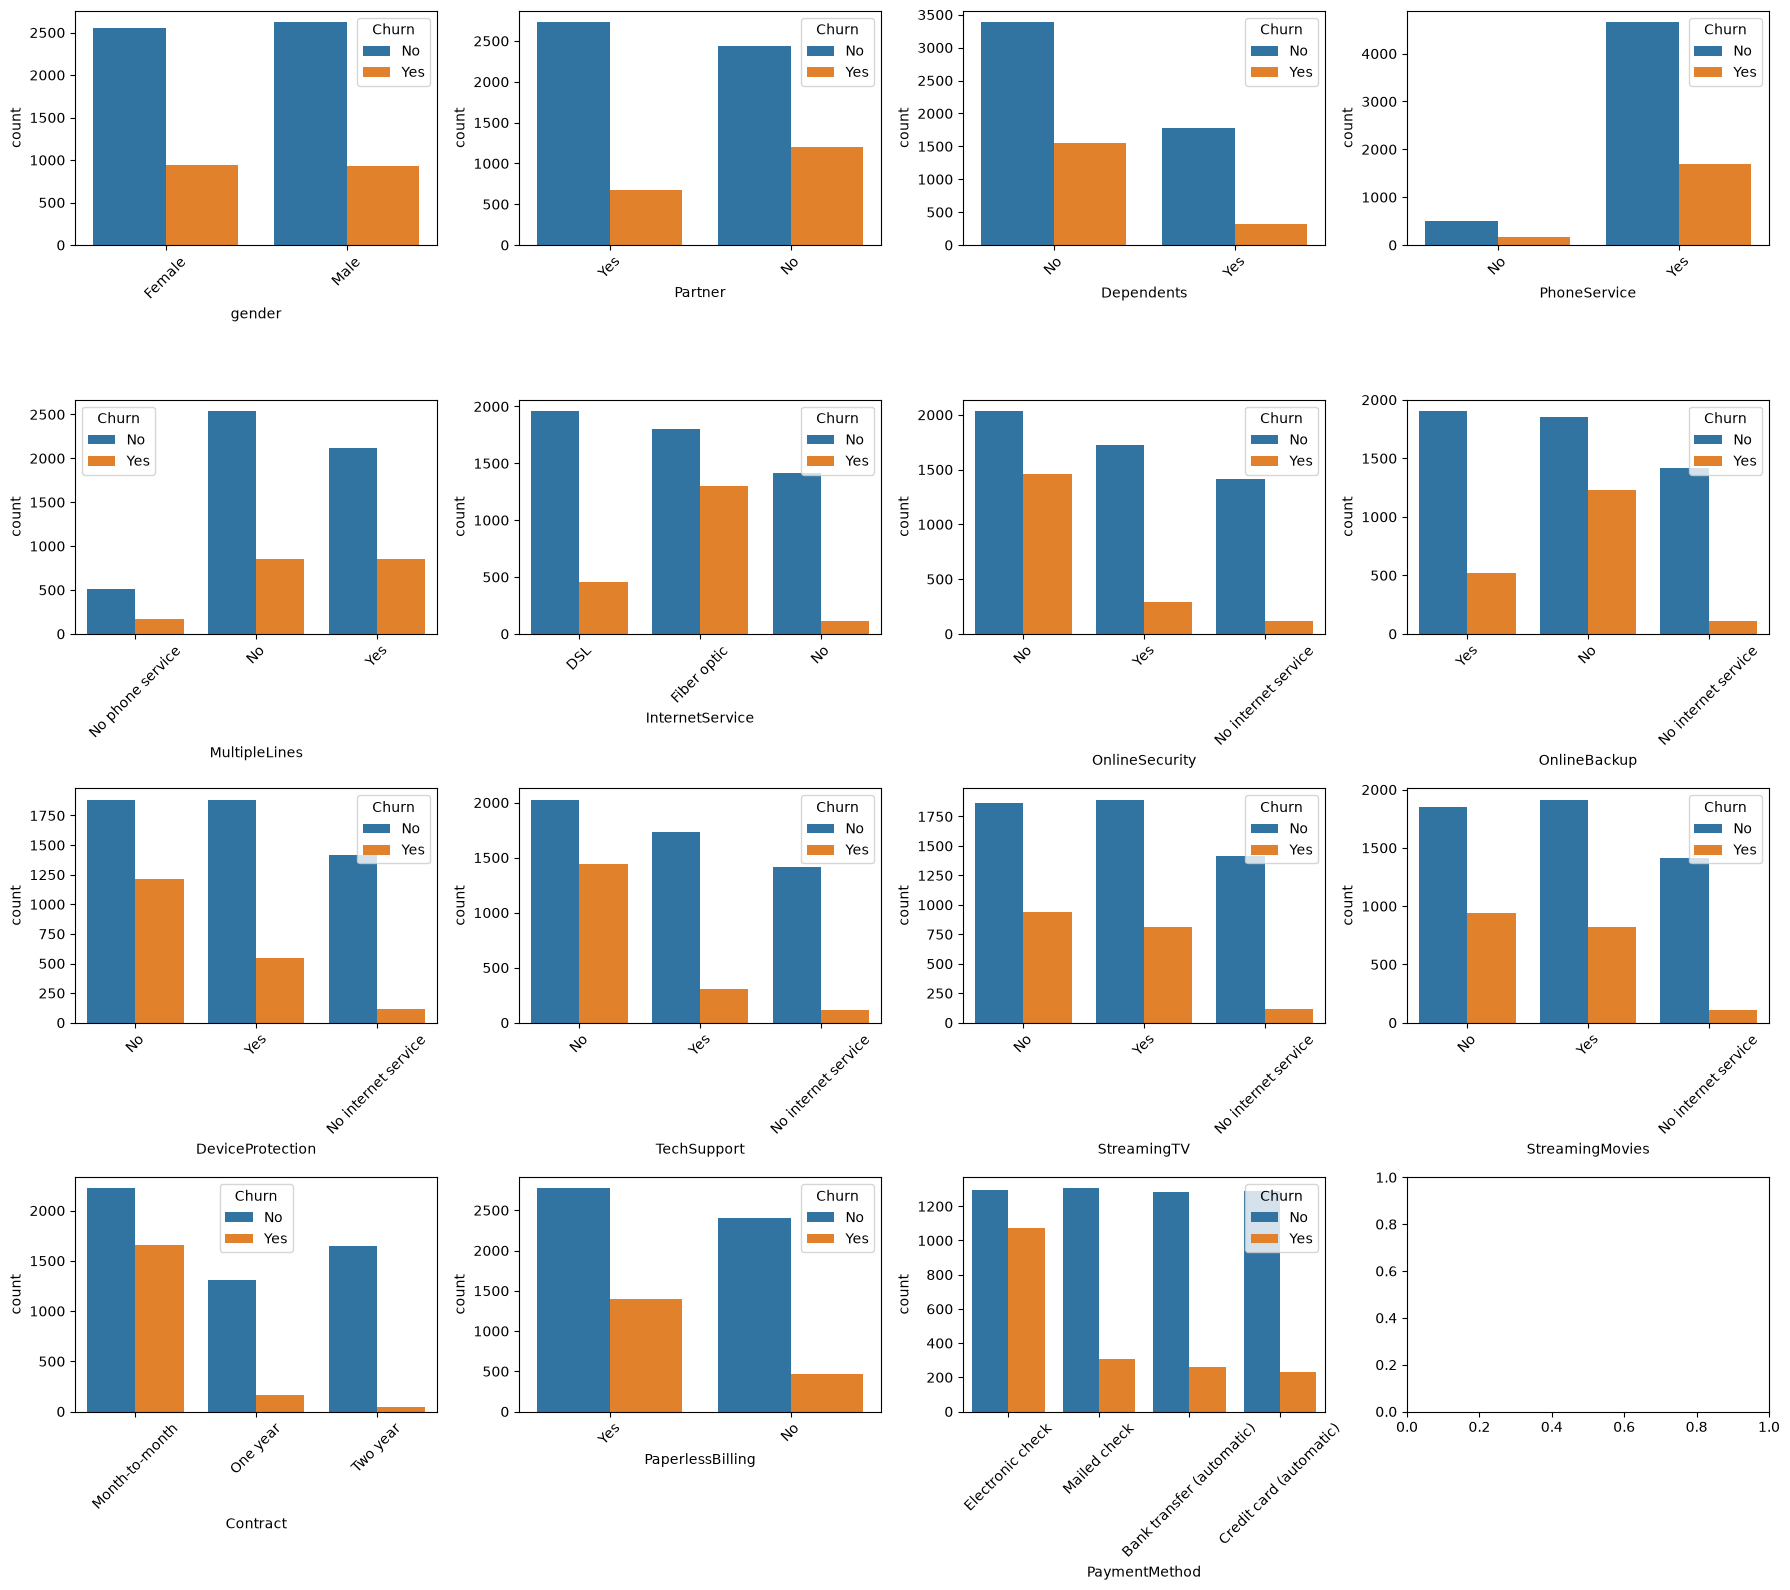

In [61]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))

for col, ax in zip(cat_cols, axes.flat):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [62]:
for col in ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']:
    churn_rate = pd.crosstab(
        df[col],
        df['Churn'],
        normalize='index'
    ) * 100

    print(f'\n{col}')
    print(churn_rate)


Contract
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858

InternetService
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980

PaymentMethod
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700

TechSupport
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


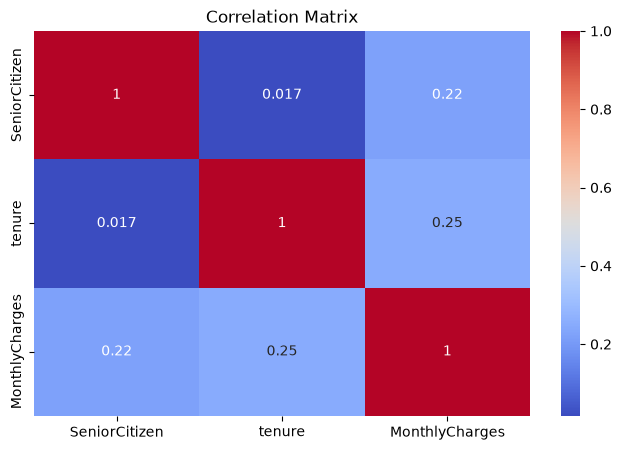

In [63]:
plt.figure(figsize=(8, 5))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

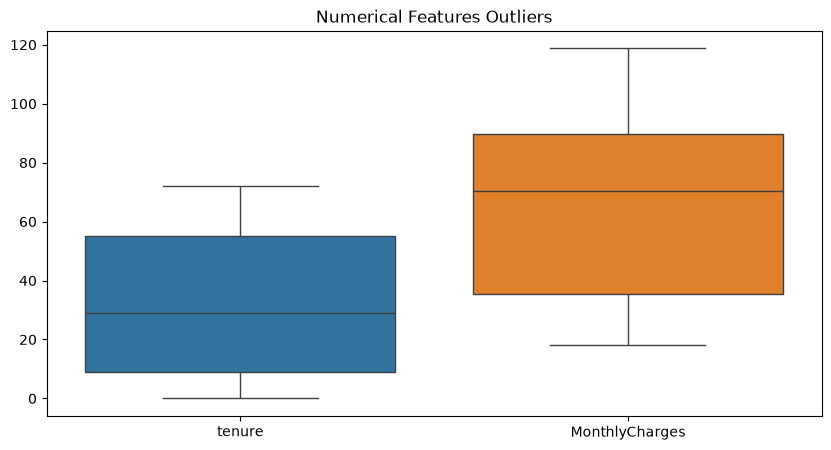

In [64]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df[['tenure', 'MonthlyCharges', 'TotalCharges']]
)

plt.title('Numerical Features Outliers')
plt.show()

In [68]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

In [70]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

In [71]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Churn'] = le.fit_transform(df['Churn'])

In [72]:
for col in binary_cols[:-1]:
    df[col] = le.fit_transform(df[col])

In [73]:
one_hot_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

In [74]:
df = pd.get_dummies(
    df,
    columns=one_hot_cols,
    drop_first=True,
    dtype=int
)

In [75]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [76]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [83]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    "Naive Bayes": GaussianNB()
}

In [86]:
res = []
for name, model in models.items():
    if name in ["KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        res.append({
            "Model": name,
            "Accuracy": accuracy,
            "F1 Score": f1
        })
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        res.append({
            "Model": name,
            "Accuracy": accuracy,
            "F1 Score": f1
        })
results_df = pd.DataFrame(res)
results_df = results_df.sort_values(by='F1 Score', ascending=False)
results_df

,Model,Accuracy,F1 Score
0,Logistic Regression,0.803407,0.599132
5,Gradient Boosting,0.798439,0.574850
7,Naive Bayes,0.655784,0.571933
2,SVM,0.792761,0.556231
4,Random Forest,0.787083,0.549550
6,XGBoost,0.774308,0.541787
1,KNN,0.747339,0.512329
3,Decision Tree,0.740951,0.502046


In [93]:
from sklearn.model_selection import cross_val_score

cv_results = []

selected_model = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

for name, model in selected_model.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:

        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring='f1'
        )

    else:

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring='f1'
        )

    cv_results.append({
        "Model": name,
        "F1 Score": scores.mean()
    })

results_df = pd.DataFrame(cv_results)

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
).reset_index(drop=True)

results_df

,Model,F1 Score
0,Logistic Regression,0.597940
1,Gradient Boosting,0.580103
2,SVM,0.576485
3,XGBoost,0.549865
4,Random Forest,0.544287
5,KNN,0.536359


In [100]:
from sklearn.model_selection import RandomizedSearchCV

#For Logistic Regression
peram_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 300, 400, 500],
    'class_weight': [None, 'balanced']
}

cv_lr = RandomizedSearchCV(
    estimator=LogisticRegression(),
    param_distributions=peram_grid_lr,
    n_iter=10,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
cv_lr.fit(X_train_scaled, y_train)

print("Best Parameters for Logistic Regression:", cv_lr.best_params_)
print("Best F1 Score for Logistic Regression:", cv_lr.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


Best Parameters for Logistic Regression: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 400, 'class_weight': 'balanced', 'C': 1}
Best F1 Score for Logistic Regression: 0.6321949898277291


In [102]:
# For Gradient Boosting
peram_grid_gb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

cv_gb = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=peram_grid_gb,
    n_iter=10,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
cv_gb.fit(X_train, y_train) 
print("Best Parameters for Gradient Boosting:", cv_gb.best_params_)
print("Best F1 Score for Gradient Boosting:", cv_gb.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Best Parameters for Gradient Boosting: {'subsample': 0.7, 'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.01}
Best F1 Score for Gradient Boosting: 0.563132533019981


In [98]:
# For SVM
peram_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4, 5]
}

cv_svm = RandomizedSearchCV(
    estimator=SVC(probability=True),
    param_distributions=peram_grid_svm,
    n_iter=10,
    scoring='f1',
    cv=5,   
    verbose=1,
    random_state=42,
    n_jobs=-1
)
cv_svm.fit(X_train_scaled, y_train)

print("Best Parameters for SVM:", cv_svm.best_params_)
print("Best F1 Score for SVM:", cv_svm.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Best Parameters for SVM: {'kernel': 'sigmoid', 'gamma': 'auto', 'degree': 5, 'C': 0.1}
Best F1 Score for SVM: 0.5887531268166692


In [103]:
best_lr_model = cv_lr.best_estimator_
best_gb_model = cv_gb.best_estimator_
best_svm_model = cv_svm.best_estimator_

lr_pred = best_lr_model.predict(X_test_scaled)
gb_pred = best_gb_model.predict(X_test)
svm_pred = best_svm_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)  
svm_accuracy = accuracy_score(y_test, svm_pred)

lr_f1 = f1_score(y_test, lr_pred)
gb_f1 = f1_score(y_test, gb_pred)
svm_f1 = f1_score(y_test, svm_pred)

pd.DataFrame({
    "Model": ["Logistic Regression", "Gradient Boosting", "SVM"],
    "Accuracy": [lr_accuracy, gb_accuracy, svm_accuracy],
    "F1 Score": [lr_f1, gb_f1, svm_f1]
}).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

,Model,Accuracy,F1 Score
0,Logistic Regression,0.738822,0.613445
1,Gradient Boosting,0.806955,0.594030
2,SVM,0.791341,0.582386


In [105]:
from sklearn.metrics import classification_report, confusion_matrix

lr_pred = best_lr_model.predict(X_test_scaled)

print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[749 286]
 [ 82 292]]


In [107]:
from sklearn.metrics import roc_auc_score

print("LR ROC-AUC:", roc_auc_score(
    y_test,
    best_lr_model.predict_proba(X_test_scaled)[:, 1]
))

LR ROC-AUC: 0.8411764705882353


In [111]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lr_model
    .coef_[0]
})

feature_importance['Abs_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Abs_Coefficient',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
4,tenure,-1.140036,1.140036
7,MonthlyCharges,-1.035075,1.035075
11,InternetService_Fiber optic,0.810313,0.810313
26,Contract_Two year,-0.619256,0.619256
8,TotalCharges,0.473468,0.473468
25,Contract_One year,-0.297096,0.297096
24,StreamingMovies_Yes,0.286619,0.286619
22,StreamingTV_Yes,0.273448,0.273448
10,MultipleLines_Yes,0.201576,0.201576
28,PaymentMethod_Electronic check,0.189332,0.189332


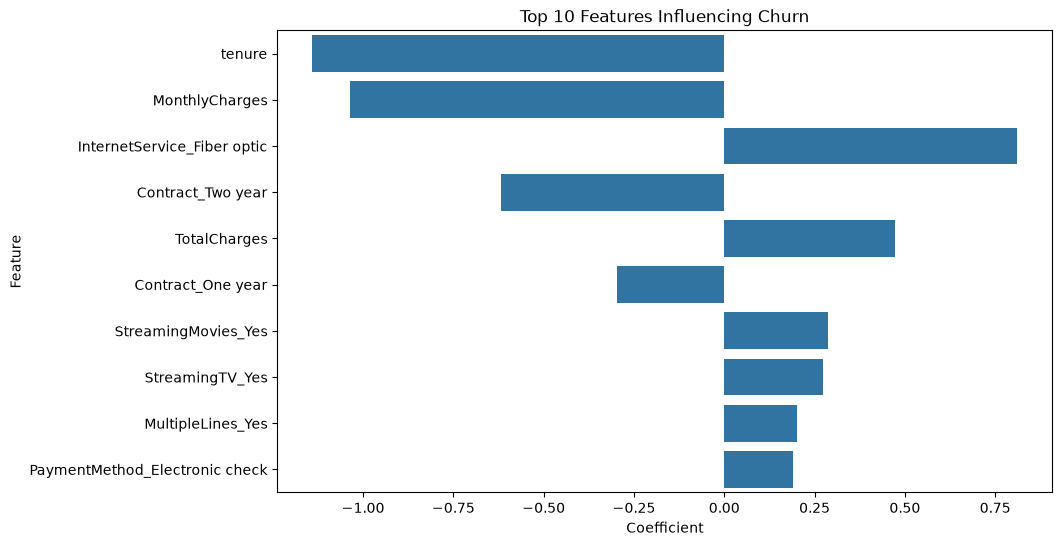

In [112]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title('Top 10 Features Influencing Churn')
plt.show()

In [113]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pred = best_lr_model.predict(X_test_scaled)
prob = best_lr_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

Accuracy: 0.7388218594748048
Precision: 0.5051903114186851
Recall: 0.7807486631016043
F1: 0.6134453781512605
ROC-AUC: 0.8411764705882353

Confusion Matrix:
[[749 286]
 [ 82 292]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [114]:
gb_pred = best_gb_model.predict(X_test)

gb_prob = best_gb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, gb_pred))
print(confusion_matrix(y_test, gb_pred))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, gb_prob)
)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

[[938  97]
 [175 199]]
ROC-AUC: 0.8466609832338733


In [116]:
import joblib

joblib.dump(best_gb_model, "gradient_boosting_model.pkl")

['gradient_boosting_model.pkl']

In [117]:
import os

print(os.path.getsize("gradient_boosting_model.pkl"))

1829098
